# FOC Monte Carlo

The firmware's law searched over the 23-63 V link sweep. No board.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

`tools/montecarlo.py` runs the firmware's own C - the current loop, the injection demodulator, the rotor observer, the dead-time table - through `test_drive_core.py`'s bench against `drive_model.c`, one process per core. A plant is drawn around the 5230SL that the controller was not told about; the cost is `sigma_theta + speed_err + 10 trip`.

In [2]:
import os
import sys

sys.path.insert(0, os.path.join('..', 'host', 'tools'))
import montecarlo as mc

print('link sweep', mc.VDC_SWEEP)
print('knobs', {k: v[:2] for k, v in mc.KNOBS.items()})
print('I_MAX %.0f  I_TRIP %.0f  I_H_MAX %.0f  TOP %.2f  LOST %.2f rad'
      % (mc.I_MAX, mc.I_TRIP, mc.I_H_MAX, mc.TOP, mc.LOST))
plant = mc.draw(1, 43.0)
print({k: round(v, 6) for k, v in plant.items()})

link sweep (23.0, 33.0, 43.0, 53.0, 63.0)
knobs {'bw_i': (300.0, 2500.0), 'f_pll': (20.0, 400.0), 'zeta': (0.5, 1.2), 'v_inj': (0.02, 0.2), 'n_inj': (1, 4), 'w_lo': (50.0, 800.0), 'w_ratio': (1.5, 4.0), 'bw_w': (1.0, 20.0)}
I_MAX 60  I_TRIP 100  I_H_MAX 5  TOP 0.50  LOST 0.35 rad
{'r': 0.039602, 'ld': 1.8e-05, 'lq': 2.1e-05, 'lambda': 0.002071, 'pole_pairs': 14.0, 'sat': 0.3, 'i_sat': 40.0, 'j': 0.000141, 'b': 0.000253, 'load': 0.0, 'v_dt': 0.082524, 'i_knee': 11.289512, 'vdc': 43.0, 'noise': 0.355632, 'theta0': 0.178112, 'sub': 4.0, 'theta_err0': 0.805836, 'k_prop': 5e-06}


A small search here so the notebook executes in minutes; the tool's defaults are 48 candidates, 16 draws and 24 refinements per link voltage.

In [3]:
import time

VDCS = (23.0, 43.0, 63.0)
t0 = time.perf_counter()
with mc.pool() as p:
    best, runs = mc.search(p, vdcs=VDCS, candidates_n=6, draws=2, refine=3)
    checked = mc.verify(p, best, draws=4)
print('%d runs in %.0f s' % (len(runs) + len(checked), time.perf_counter() - t0))
best[['vdc', 'mean', 'p90', 'robust'] + list(mc.KNOBS)].round(4)

round 1: 36 runs


      3 / 36 runs, 1 s
      6 / 36 runs, 1 s
      9 / 36 runs, 1 s
     12 / 36 runs, 1 s
     15 / 36 runs, 1 s
     18 / 36 runs, 1 s
     21 / 36 runs, 1 s
     24 / 36 runs, 1 s
     27 / 36 runs, 1 s
     30 / 36 runs, 1 s
     33 / 36 runs, 1 s
     36 / 36 runs, 1 s
round 2: 18 runs


      1 / 18 runs, 1 s
      2 / 18 runs, 1 s
      3 / 18 runs, 1 s
      4 / 18 runs, 1 s
      5 / 18 runs, 1 s
      6 / 18 runs, 1 s
      7 / 18 runs, 1 s
      8 / 18 runs, 1 s
      9 / 18 runs, 1 s
     10 / 18 runs, 1 s
     11 / 18 runs, 1 s
     12 / 18 runs, 1 s
     13 / 18 runs, 1 s
     14 / 18 runs, 1 s
     15 / 18 runs, 1 s
     16 / 18 runs, 1 s
     17 / 18 runs, 1 s
     18 / 18 runs, 1 s


      2 / 24 runs, 1 s
      4 / 24 runs, 1 s
      6 / 24 runs, 1 s
      8 / 24 runs, 1 s
     10 / 24 runs, 1 s
     12 / 24 runs, 1 s
     14 / 24 runs, 1 s
     16 / 24 runs, 1 s
     18 / 24 runs, 1 s
     20 / 24 runs, 1 s
     22 / 24 runs, 1 s
     24 / 24 runs, 1 s
78 runs in 4 s


,vdc,mean,p90,robust,bw_i,f_pll,zeta,v_inj,n_inj,w_lo,w_ratio,bw_w
0,23.0,0.0395,0.0441,0.0835,1186.9727,83.2030,0.5324,0.1997,1,127.0412,1.5361,3.9600
1,43.0,0.0468,0.0482,0.0950,947.7112,50.0143,0.5026,0.1338,1,100.2445,1.5214,2.6917
2,63.0,0.0584,0.0624,0.1209,947.7112,50.0143,0.5026,0.1338,1,100.2445,1.5214,2.6917


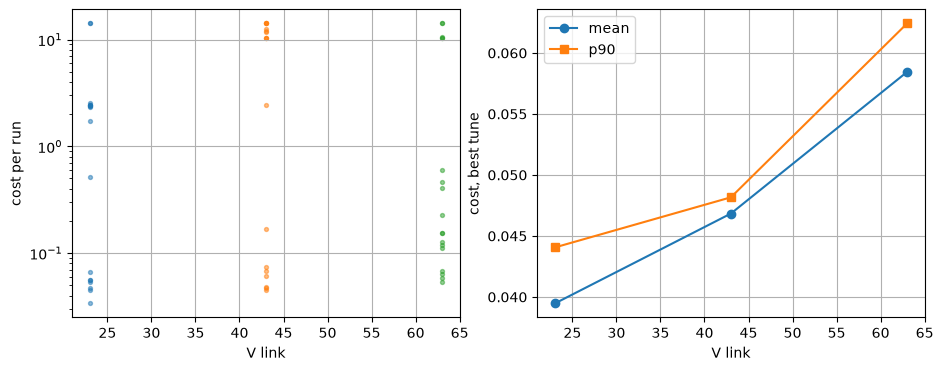

In [4]:
import matplotlib.pyplot as plt

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
for vdc in VDCS:
    sub = runs[runs.vdc == vdc]
    a.scatter([vdc] * len(sub), sub.cost, s=8, alpha=0.5)
a.set_xlabel('V link'); a.set_ylabel('cost per run'); a.set_yscale('log'); a.grid(True)
b.plot(best.vdc, best['mean'], 'o-', label='mean'); b.plot(best.vdc, best.p90, 's-', label='p90')
b.set_xlabel('V link'); b.set_ylabel('cost, best tune'); b.legend(); b.grid(True)
plt.show()

The sensorless floor: the verification runs the best tune with the injection off through the descent and reports the speed the back-EMF alone loses the rotor at.

In [5]:
bemf = checked[checked.bemf_only]
floor = bemf.groupby('vdc')['min_rpm'].agg(['mean', 'max', 'count'])
print(floor.round(0))
print('trips with injection: %d of %d' % (int(checked[~checked.bemf_only].trip.sum()),
                                          int((~checked.bemf_only).sum())))
print('sigma_theta rms, injection on, per link:')
print(checked[~checked.bemf_only].groupby('vdc')['sigma_theta'].mean().round(4))

      mean   max  count
vdc                    
23.0  31.0  35.0      4
43.0  10.0  22.0      4
63.0  14.0  30.0      4
trips with injection: 0 of 12
sigma_theta rms, injection on, per link:
vdc
23.0    0.0388
43.0    0.0475
63.0    0.0766
Name: sigma_theta, dtype: float64


## Conclusions

In [6]:
import math

print('runs             %d in the search, %d in the verification' % (len(runs), len(checked)))
print('draws per point  %d plants, each drawn around the 5230SL' % 2)
print('cost             sigma_theta + speed_err + 10 x trip')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = checked[(checked.vdc == vdc) & (~checked.bemf_only)]
    print('%4.0f V  robust %.3f  bw_i %6.0f Hz  f_pll %5.0f Hz  v_inj %.3f  n_inj %d'
          % (vdc, row.robust, row.bw_i, row.f_pll, row.v_inj, int(row.n_inj)))
    print('        verified sigma_theta %.4f rad (%.2f deg), trips %d of %d'
          % (sub.sigma_theta.mean(), math.degrees(sub.sigma_theta.mean()),
             int(sub.trip.sum()), len(sub)))

runs             54 in the search, 24 in the verification
draws per point  2 plants, each drawn around the 5230SL
cost             sigma_theta + speed_err + 10 x trip
  23 V  robust 0.084  bw_i   1187 Hz  f_pll    83 Hz  v_inj 0.200  n_inj 1
        verified sigma_theta 0.0388 rad (2.22 deg), trips 0 of 4
  43 V  robust 0.095  bw_i    948 Hz  f_pll    50 Hz  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0475 rad (2.72 deg), trips 0 of 4
  63 V  robust 0.121  bw_i    948 Hz  f_pll    50 Hz  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0766 rad (4.39 deg), trips 0 of 4


The C is the firmware's own - current loop, demodulator, observer, dead-time table - built by `test_drive_core.py`'s harness with the host compiler and driven through ctypes against `drive_model.c`. The speed loop over it is `coaxial.loop`.

**The plant is never what the controller was told**, which is what makes the cost a robustness figure: copper to 125 C on R, a quarter either way on L, saliency from barely there to 1.5, the dead time either side of the commissioned one, the AFE at its measured floor, the rotor inside the injection's pull-in.

A run is a lock from a random error, a raised cosine to half the link's no-load speed, a hold, a descent. The verification repeats it with the injection off through the descent, and `min_rpm` is where the back-EMF alone lost the rotor - the sensorless floor.

## Expected performance

In [7]:
import math
from coaxial import inverter
from coaxial.motor import PLATINUM_5230SL, APC20x10E, RATINGS, KT_NM_PER_AMP

TWO_PI = 2.0 * math.pi
motor = PLATINUM_5230SL
kt = 1.5 * motor.poles * motor.lam
print('Kt               %.4f N.m/A  (the sheet: %.4f)' % (kt, KT_NM_PER_AMP))
print('board rating     %.0f A instantaneous, %.0f V link' % (100.0, 63.0))
print('motor rating     %.1f A burst for %.0f s, %.0f W' % (RATINGS['i_max'], RATINGS['t_i_max'], RATINGS['p_max']))
print('the limit        %s' % ('the inverter' if 100.0 < RATINGS['i_max'] else 'the motor'))
print()
print('with an APC20x10E on the shaft, the operating point:')
print('link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by')
for vdc in (23.0, 33.0, 43.0, 53.0, 63.0):
    w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam
    no_load = w_e / motor.poles
    # Where k w^2 meets the torque the current ceiling makes, or the link's
    # own speed ceiling - whichever comes first.
    by_current = math.sqrt(kt * 100.0 / APC20x10E.k)
    wm = min(by_current, no_load)
    torque = APC20x10E.k * wm * wm
    iq = torque / kt
    print('%4.0f V %10.0f %11.0f %7.2f %10.2f %7.1f %12.1f   %s'
          % (vdc, no_load * 60.0 / TWO_PI, wm * 60.0 / TWO_PI, torque,
             torque * wm / 1000.0, iq, iq / math.sqrt(2.0),
             'the link' if wm < by_current else 'the 100 A rating'))

Kt               0.0435 N.m/A  (the sheet: 0.0435)
board rating     100 A instantaneous, 63 V link
motor rating     112.5 A burst for 42 s, 4985 W
the limit        the inverter

with an APC20x10E on the shaft, the operating point:
link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by
  23 V       4151        4151    0.97       0.42    22.3         15.8   the link
  33 V       5956        5956    2.00       1.25    46.0         32.5   the link
  43 V       7762        7762    3.40       2.76    78.1         55.2   the link
  53 V       9566        8785    4.35       4.00   100.0         70.7   the 100 A rating
  63 V      11371        8785    4.35       4.00   100.0         70.7   the 100 A rating


The no-load speed is what the modulator can hold against the back-EMF: `V_FRAC Vdc/sqrt(3) / lambda`, with V_FRAC 0.95 of the link the vector may use. The held speed is where the propeller's `k w^2` meets the torque the current ceiling makes, or that no-load speed - whichever comes first, which is what the last column names. Torque and top speed do not coexist: the shaft power column is at the operating point, not the product of the two ceilings.

In [8]:
from coaxial import sensorless

print('what the search chose, and what it implies:')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = checked[(checked.vdc == vdc) & (~checked.bemf_only)]
    bemf_rpm = floor.loc[vdc, 'mean'] if vdc in floor.index else float('nan')
    w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam
    top_rpm = w_e / motor.poles * 60.0 / TWO_PI
    f_inj = 50e3 / (2.0 * int(row.n_inj))
    print()
    print('%4.0f V' % vdc)
    print('   current loop   %.0f Hz of the %.0f Hz two periods of delay allow'
          % (row.bw_i, 50e3 * 0.05))
    print('   observer       %.0f Hz, zeta %.2f' % (row.f_pll, row.zeta))
    print('   injection      %.0f Hz at %.1f %% of Vdc/sqrt3, %d period(s)'
          % (f_inj, 100.0 * row.v_inj, int(row.n_inj)))
    print('   blend          %.0f to %.0f rad/s electrical = %.0f to %.0f rpm'
          % (row.w_lo, row.w_lo * row.w_ratio,
             row.w_lo / motor.poles * 60.0 / TWO_PI,
             row.w_lo * row.w_ratio / motor.poles * 60.0 / TWO_PI))
    print('   held           sigma_theta %.2f deg electrical, %.3f deg mechanical'
          % (math.degrees(sub.sigma_theta.mean()),
             math.degrees(sub.sigma_theta.mean()) / motor.poles))
    print('   back-EMF alone loses the rotor at %.0f rpm = %.1f %% of the %.0f rpm this link holds'
          % (bemf_rpm, 100.0 * bemf_rpm / top_rpm, top_rpm))

what the search chose, and what it implies:

  23 V
   current loop   1187 Hz of the 2500 Hz two periods of delay allow
   observer       83 Hz, zeta 0.53
   injection      25000 Hz at 20.0 % of Vdc/sqrt3, 1 period(s)
   blend          127 to 195 rad/s electrical = 87 to 133 rpm
   held           sigma_theta 2.22 deg electrical, 0.159 deg mechanical
   back-EMF alone loses the rotor at 31 rpm = 0.8 % of the 4151 rpm this link holds

  43 V
   current loop   948 Hz of the 2500 Hz two periods of delay allow
   observer       50 Hz, zeta 0.50
   injection      25000 Hz at 13.4 % of Vdc/sqrt3, 1 period(s)
   blend          100 to 153 rad/s electrical = 68 to 104 rpm
   held           sigma_theta 2.72 deg electrical, 0.194 deg mechanical
   back-EMF alone loses the rotor at 10 rpm = 0.1 % of the 7762 rpm this link holds

  63 V
   current loop   948 Hz of the 2500 Hz two periods of delay allow
   observer       50 Hz, zeta 0.50
   injection      25000 Hz at 13.4 % of Vdc/sqrt3, 1 period(s)


The current loop's ceiling is a twentieth of the sampling rate, two periods of pipeline delay wanting the phase margin, and the injection stays eight times above whatever it ended up at or the two fight. The observer's bandwidth is no knob: `kalman_gains` iterates the Riccati recursion to its fixed point, so the measured noise sets it and quieter shunts give a faster observer.

`w_lo .. w_hi` is where the estimate hands over from injection to back-EMF, and `min_rpm` is the other side of that number.

The floor is the AFE's: the demodulated angle error is `sigma_i` over the demodulator's gain, and that gain is `V_inj Ts (Lq - Ld) / (2 Ld Lq)`. The 5230SL's saliency of about 1.3 is what the zero-speed method rests on; less, and `decide` picks I/f at its 10 dB threshold.

## Two back-EMF observers

The firmware holds the rotor at rest by injecting and demodulating, and blends to back-EMF above `w_lo`. Two observers do that upper half, both in `coaxial.sensorless`, both fed by nothing but the phase voltages and currents. They are run here over plants drawn with the same tolerances the search used.

In [9]:
import math
from coaxial.loop import CurrentLoop, Machine, Signals
from coaxial.motor import Parameters
from coaxial import sensorless

SPEEDS = (20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0)
PLANTS = 5

def observe(plant, w_e, seconds=0.4):
    """Both observers against a rotor held at w_e, error in degrees rms."""
    fitted = Parameters(name='drawn', r=plant['r'], ld=plant['ld'],
                        lq=plant['lq'], lam=plant['lambda'],
                        poles=int(plant['pole_pairs']), measured=False)
    dt = 2.0 * inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    smo = sensorless.SlidingModeObserver(
        fitted.r, fitted.ld, k=1.5 * fitted.lam * abs(w_e) + 1.0)
    flux = sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0)
    s = Signals()
    s.iq_ref = 2.0
    got = {'smo': [], 'flux': [], 'gap': []}
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        c, sn = math.cos(s.theta), math.sin(s.theta)
        va, vb = s.vd * c - s.vq * sn, s.vd * sn + s.vq * c
        ia, ib = s.id * c - s.iq * sn, s.id * sn + s.iq * c
        th_s = smo.update(va, vb, ia, ib, dt)
        th_f = flux.update(va, vb, ia, ib, dt)
        if s.t > 0.5 * seconds:
            got['smo'].append(sensorless._wrap(th_s - s.theta))
            got['flux'].append(sensorless._wrap(th_f - s.theta))
            got['gap'].append(sensorless._wrap(th_s - th_f))
    return {k: math.degrees(math.sqrt(sum(e * e for e in v) / len(v)))
            for k, v in got.items()}

plants = [mc.draw(90 + i, 43.0) for i in range(PLANTS)]
print('  rad/s el    rpm      SMO deg rms       flux deg rms     apart')
print('                     median  worst     median  worst       deg')
table = []
for w_e in SPEEDS:
    rows = [observe(p, w_e) for p in plants]
    smo = sorted(r['smo'] for r in rows)
    flux = sorted(r['flux'] for r in rows)
    gap = sorted(r['gap'] for r in rows)
    table.append((w_e, smo, flux, gap))
    print('%10.0f %6.0f %11.1f %6.1f %10.1f %6.1f %9.1f'
          % (w_e, w_e / motor.poles * 60.0 / TWO_PI,
             smo[len(smo) // 2], smo[-1], flux[len(flux) // 2], flux[-1],
             gap[len(gap) // 2]))

  rad/s el    rpm      SMO deg rms       flux deg rms     apart
                     median  worst     median  worst       deg


        20     14        18.5   19.6       52.9   53.0      55.1


        50     34         7.4    7.8       36.0   36.1      36.4


       100     68         4.3    4.8       23.3   23.3      23.4


       200    136         2.7    3.0       12.0   12.0      11.9


       500    341         2.2    2.2        5.4    5.4       5.7


      1000    682         3.0    3.1        3.5    3.5       4.9


      2000   1364         5.5    5.7        3.2    3.3       7.4


A torque command at an angle error of `eps` delivers `cos(eps)` of itself: 20 degrees electrical costs 6 %, 40 degrees costs 23 %. Taking 20 degrees as the line:

In [10]:
CRITERION_DEG = 20.0

def floor_of(which):
    """Lowest swept speed whose worst plant stays inside the criterion."""
    column = {'smo': 1, 'flux': 2}[which]
    for row in table:
        if row[column][-1] <= CRITERION_DEG:
            return row[0]
    return None

def ceiling_of(which):
    """Highest swept speed still inside it."""
    column = {'smo': 1, 'flux': 2}[which]
    inside = [row[0] for row in table if row[column][-1] <= CRITERION_DEG]
    return max(inside) if inside else None

def rpm(w_e):
    return w_e / motor.poles * 60.0 / TWO_PI

for which, name in (('smo', 'sliding mode'), ('flux', 'flux linkage')):
    lo, hi = floor_of(which), ceiling_of(which)
    print('%-14s inside %.0f deg from %5.0f to %5.0f rad/s = %4.0f to %5.0f rpm'
          % (name, CRITERION_DEG, lo, hi, rpm(lo), rpm(hi)))
print()
print('the firmware blends to back-EMF at w_lo, chosen per link above:')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    print('   %4.0f V  w_lo %.0f rad/s = %.0f rpm' % (vdc, row.w_lo, rpm(row.w_lo)))

sliding mode   inside 20 deg from    20 to  2000 rad/s =   14 to  1364 rpm
flux linkage   inside 20 deg from   200 to  2000 rad/s =  136 to  1364 rpm

the firmware blends to back-EMF at w_lo, chosen per link above:
     23 V  w_lo 127 rad/s = 87 rpm
     43 V  w_lo 100 rad/s = 68 rpm
     63 V  w_lo 100 rad/s = 68 rpm


### Sliding mode observer

The stator's current equation run as a model, with a switching term driving the model's current onto the measured one. Once it slides, that term is the only thing the model was missing, which is the back-EMF; low-passing it is the estimate, and `e = lambda w (-sin, cos)` gives the angle.

`k` has to exceed the back-EMF the machine can make, so it is sized from `lambda w_max` rather than tuned. It degrades at **both** ends and for different reasons. Low down the back-EMF is small against `R i` and the boundary layer, so the error grows as the signal shrinks. High up the low-pass lag `atan(w/wc)` becomes a large correction - 76 degrees at 2000 rad/s with `wc` 500 - and a large correction rests heavily on the speed estimate underneath it, which is why the error turns back up at the top of the sweep.

It needs R and L, and it is the pair it is least sensitive to: the switching term absorbs what the model gets wrong, which is the point of it.

### Flux linkage observer

`psi = integral of (v - R i)` is the stator's flux linkage, and `psi - L i` is the rotor's, whose angle is the rotor's. Nothing is differentiated and nothing switches, so it is quiet where it works.

The integrator is the whole difficulty. A pure one walks away on any offset in v, in the current, or in R, so this leaks at `wc` - and that costs exactly what it saves: the estimate comes out `sqrt(1 + (wc/w)^2)` short and `atan(wc/w)` late, and the correction for it is only as good as the speed it rests on. At `w = wc` the correction is 45 degrees; below it, the observer has nothing.

Above the corner it is the better of the two, and by a growing margin: no lag to compensate, and lambda comes out of it directly, so the estimate's magnitude is a check on the machine as well as its angle.

### Running both

They fail at opposite ends, and the `apart` column above is what makes running both practical: in the band where both are inside the criterion they agree to within a few degrees, so a handover between them moves the estimate by less than the estimate's own error.

In [11]:
both = [row for row in table
        if row[1][-1] <= CRITERION_DEG and row[2][-1] <= CRITERION_DEG]
if both:
    print('both inside %.0f deg from %.0f to %.0f rad/s = %.0f to %.0f rpm'
          % (CRITERION_DEG, both[0][0], both[-1][0], rpm(both[0][0]), rpm(both[-1][0])))
    print('   they disagree by %.1f to %.1f deg across that band'
          % (min(r[3][0] for r in both), max(r[3][-1] for r in both)))
    cross = min(table, key=lambda r: abs(r[1][len(r[1]) // 2] - r[2][len(r[2]) // 2]))
    print('   equally good at about %.0f rad/s = %.0f rpm' % (cross[0], rpm(cross[0])))
else:
    print('no speed in this sweep has both inside %.0f deg' % CRITERION_DEG)
print()
print('cost, per step, on top of what the drive already computes:')
print('   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2')
print('   flux linkage   2 integrators, one atan2, and a sqrt and atan for the lag')
print('   the drive runs at %.0f kHz with %d cycles of headroom in its ISR'
      % (1e-3 / inverter.TS, 2 * 2375 - 2921))

both inside 20 deg from 200 to 2000 rad/s = 136 to 1364 rpm
   they disagree by 4.9 to 12.0 deg across that band
   equally good at about 1000 rad/s = 682 rpm

cost, per step, on top of what the drive already computes:
   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2
   flux linkage   2 integrators, one atan2, and a sqrt and atan for the lag
   the drive runs at 50 kHz with 1829 cycles of headroom in its ISR


Running both is cheap - each is a couple of integrators and an `atan2` against a step the drive already spends thousands of cycles on - and the useful part is not redundancy but coverage: the sliding-mode observer covers from the injection's hand-over up to where its own lag correction gets stiff, and the flux observer covers from its corner upward without bound.

Switching between them wants two things. A **hysteresis band**, because a threshold sitting where both are marginal is a threshold the estimate will chatter across, and the estimate is what the commutation rests on. And a **blend rather than a jump** - the same shape the firmware already uses between injection and back-EMF over `w_lo .. w_hi` - since the two disagree by a few degrees in the overlap and a step of that size in the commutation angle is a step in torque.

That gives one chain across the whole range: injection at rest and below `w_lo`, sliding mode through the middle, flux linkage at the top, each handing over inside a band where the next one is already good. What the firmware runs today is the first of those handovers; the second is arithmetic here and nothing on the board.

## The envelope, with the tolerances in it

Every number below moves with lambda, and the plants are drawn with lambda at +/- 10 %: speed goes as `1/lambda` and torque as `lambda`, so the two ends of the tolerance are the two ends of the envelope.

In [12]:
LAMBDA_SPREAD = (0.9, 1.1)          # what mc.draw draws over
I_RATING = 100.0                    # the board, instantaneous

print('link   no-load rpm            torque at 100 A       shaft kW at that torque')
print('         min    max            min     max            min     max')
for vdc in (23.0, 43.0, 63.0):
    speeds, torques, powers = [], [], []
    for f in LAMBDA_SPREAD:
        lam = motor.lam * f
        w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / lam
        kt = 1.5 * motor.poles * lam
        speeds.append(w_e / motor.poles * 60.0 / TWO_PI)
        torques.append(kt * I_RATING)
        # At the propeller's operating point, not at both ceilings at once.
        wm = min(math.sqrt(kt * I_RATING / APC20x10E.k), w_e / motor.poles)
        powers.append(APC20x10E.k * wm * wm * wm / 1000.0)
    print('%4.0f V %7.0f %6.0f %14.2f %7.2f %14.2f %7.2f'
          % (vdc, min(speeds), max(speeds), min(torques), max(torques),
             min(powers), max(powers)))

link   no-load rpm            torque at 100 A       shaft kW at that torque
         min    max            min     max            min     max
  23 V    3774   4613           3.92    4.79           0.32    0.58
  43 V    7056   8624           3.92    4.79           2.07    3.42
  63 V   10338  12635           3.92    4.79           3.42    4.62


In [13]:
from coaxial import thermal

R_PHASE = inverter.RDS_ON + inverter.SHUNT
CEILING_C = 125.0 * 0.85            # the record's throttle point
AMBIENT_C = thermal.AMBIENT
capacity = thermal.CFG['capacity']['phase_u']

# The same definition thermal_model.ipynb uses: the worst node's
# equilibrium against the ceiling, housekeeping and drivers included.
i_rms = thermal.continuous_amps(R_PHASE, CEILING_C)
iq_cont = i_rms * math.sqrt(2.0)
kt = 1.5 * motor.poles * motor.lam
print('continuous, worst node at the %.1f C throttle point:' % CEILING_C)
print('   %.1f A rms a phase = %.1f A of iq = %.2f N.m'
      % (i_rms, iq_cont, kt * iq_cont))
print()
print('burst from ambient, the node on its own capacity (%.2f J/K):' % capacity)
print('   iq A   A rms   W a phase   K/s      s to the ceiling')
for iq in (20.0, 40.0, 60.0, 100.0):
    rms = iq / math.sqrt(2.0)
    p = rms * rms * R_PHASE
    print('%7.0f %7.1f %11.1f %7.1f %17.2f'
          % (iq, rms, p, p / capacity, (CEILING_C - AMBIENT_C) / (p / capacity)))

continuous, worst node at the 106.2 C throttle point:
   13.3 A rms a phase = 18.8 A of iq = 0.82 N.m

burst from ambient, the node on its own capacity (0.40 J/K):
   iq A   A rms   W a phase   K/s      s to the ceiling
     20    14.1         1.1     2.6             32.55
     40    28.3         4.2    10.6              8.14
     60    42.4         9.5    23.8              3.62
    100    70.7        26.5    66.2              1.30


The rate at the start of a burst is `P / capacity` and nothing else: the node holds a third of a joule per kelvin, so it moves in seconds while the board under it moves in 6.8 minutes. That separation is why a burst is planned against `seconds_to_limit` rather than a steady state, and why the envelope throttles at 85 % of the ceiling rather than waiting for it.

The network was fitted **dry** - nothing on the phases, nothing through the hot swap - so the phase node's `to_board` is the first number to re-fit with current flowing: `(T_zone - T_board) / P` off a camera, into `thermal.set_node`. Everything in this section moves with it.

## The envelope

In [14]:
def band(f):
    """(min, max) of f over the lambda tolerance."""
    got = [f(motor.lam * s) for s in LAMBDA_SPREAD]
    return min(got), max(got)

top = band(lambda lam: inverter.V_FRAC * 63.0 / math.sqrt(3.0) / lam
           / motor.poles * 60.0 / TWO_PI)
low = band(lambda lam: inverter.V_FRAC * 23.0 / math.sqrt(3.0) / lam
           / motor.poles * 60.0 / TWO_PI)
peak = band(lambda lam: 1.5 * motor.poles * lam * I_RATING)
cont = band(lambda lam: 1.5 * motor.poles * lam * iq_cont)
smo_rpm = floor_of('smo')
flux_rpm = floor_of('flux')
bemf = floor.loc[43.0, 'mean'] if 43.0 in floor.index else float('nan')

print('%-34s %s' % ('MAXIMUM SPEED, no load',
                    '%.0f to %.0f rpm at 63 V' % top))
print('%-34s %s' % ('', '%.0f to %.0f rpm at 23 V' % low))
print('%-34s %s' % ('MINIMUM SPEED, injection', '0 rpm - it holds at rest'))
print('%-34s %.0f rpm' % ('   back-EMF alone, firmware', bemf))
print('%-34s %.0f rpm' % ('   sliding mode, 20 deg', smo_rpm / motor.poles * 60.0 / TWO_PI))
print('%-34s %.0f rpm' % ('   flux linkage, 20 deg', flux_rpm / motor.poles * 60.0 / TWO_PI))
print('%-34s %s' % ('PEAK TORQUE, 100 A instantaneous',
                    '%.2f to %.2f N.m' % peak))
print('%-34s %s' % ('CONTINUOUS TORQUE, thermal',
                    '%.2f to %.2f N.m (%.1f A of iq)' % (cont[0], cont[1], iq_cont)))
print('%-34s %.2f s at 100 A, %.2f s at 60 A'
      % ('BURST TO THE THROTTLE POINT',
         (CEILING_C - AMBIENT_C) / ((100.0 / math.sqrt(2.0)) ** 2 * R_PHASE / capacity),
         (CEILING_C - AMBIENT_C) / ((60.0 / math.sqrt(2.0)) ** 2 * R_PHASE / capacity)))
print('%-34s %.1f to %.1f deg electrical'
      % ('ANGLE ERROR, injection held',
         math.degrees(checked[~checked.bemf_only].sigma_theta.min()),
         math.degrees(checked[~checked.bemf_only].sigma_theta.max())))

MAXIMUM SPEED, no load             10338 to 12635 rpm at 63 V
                                   3774 to 4613 rpm at 23 V
MINIMUM SPEED, injection           0 rpm - it holds at rest
   back-EMF alone, firmware        10 rpm
   sliding mode, 20 deg            14 rpm
   flux linkage, 20 deg            136 rpm
PEAK TORQUE, 100 A instantaneous   3.92 to 4.79 N.m
CONTINUOUS TORQUE, thermal         0.74 to 0.90 N.m (18.8 A of iq)
BURST TO THE THROTTLE POINT        1.30 s at 100 A, 3.62 s at 60 A
ANGLE ERROR, injection held        1.8 to 6.6 deg electrical


Speed goes as `1/lambda` and torque as `lambda`, so the +/- 10 % the plants are drawn over puts a 22 % spread on both. The link sets the speed and the board's 100 A sets the torque; neither is the motor, whose 112.5 A burst sits above the rating.

**Continuous torque is a fifth of peak**, and that is the thermal network rather than the stage. Everything above it is a burst measured in seconds, which is what `thermal_budget.ipynb` plans against `seconds_to_limit`.

**The floor is the injection's**, not an observer's: the injection holds at rest and the back-EMF observers do not.

## Reference values for a low-saliency machine

An outrunner is the case this has to survive. Saliency is what the injection lives on - the demodulator's gain goes as `Lq - Ld` - and an outrunner's magnets sit on the rotor surface, so there is little of it. The plants here are drawn from 1.05 to 1.5, which spans the case where injection works and the case where it does not.

In [15]:
from coaxial import sensorless

k = {'ld': motor.ld, 'lq': motor.lq, 'sigma_i': max(inverter.NOISE_A),
     'vdc': 43.0, 'r': motor.r, 'i_max': I_RATING}
loop_hz = sensorless.current_loop(k['r'], k['ld'], 1.0 / inverter.TS,
                                  k['sigma_i'], k['vdc'])['bw_hz']
print('             ---- 5 A of HF headroom ----   ---- 1 A ----')
print('saliency   SNR dB   method    i_h peak A   SNR dB   method')
for ratio in (1.02, 1.05, 1.15, 1.32, 1.5):
    lq = motor.ld * ratio
    row = [ratio]
    for cap in (5.0, 1.0):
        choice = sensorless.choose_injection(
            motor.ld, lq, k['sigma_i'], 1.0 / inverter.TS, 50.0, k['vdc'],
            i_h_max=cap, bw_i_hz=loop_hz)
        row.append(choice)
    wide, tight = row[1], row[2]
    print('%8.2f %8.1f   %-9s %10.2f %8.1f   %-9s'
          % (ratio, wide['snr_db'], sensorless.decide(wide['snr_db']),
             wide['i_h_peak'],
             tight['snr_db'], sensorless.decide(tight['snr_db'])))
print()
print('the 5230SL sits at %.2f, sigma_i %.2f A rms' % (motor.saliency, k['sigma_i']))

             ---- 5 A of HF headroom ----   ---- 1 A ----
saliency   SNR dB   method    i_h peak A   SNR dB   method
    1.02     10.7   injection       2.26      3.6   if_start 
    1.05     18.4   injection       2.26     11.3   injection
    1.15     20.0   injection       0.99     20.0   injection
    1.32     20.0   injection       0.53     20.0   injection
    1.50     20.0   injection       0.39     20.0   injection

the 5230SL sits at 1.32, sigma_i 0.41 A rms


At this AFE's noise floor the injection clears the 10 dB threshold all the way down to 1.02, so the answer is not that a low-saliency machine cannot be held at rest. What falls is the exchange rate: the same angle information costs 0.39 A of HF current at 1.5 saliency and 2.26 A at 1.05, and that current is loss and acoustic noise in the machine for no torque at all. Cap the HF current and the method changes on its own - the right-hand columns are the same machines with 1 A of headroom instead of 5.

So `i_h_max` is the knob a low-saliency machine is set up around, and where it forces `if_start` the drive ramps open-loop on current until the back-EMF is readable, with a saturation pulse to settle which end of the axis the magnet is. That makes the back-EMF observers the whole strategy above the ramp, and their low-speed limit the binding one:

In [16]:
hand_over = floor_of('smo')
print('CONTROL STRATEGY, low saliency')
print('   below the hand-over      I/f ramp on current, saturation pulse for polarity')
print('   hand-over at             %.0f rad/s = %.0f rpm, the sliding-mode floor'
      % (hand_over, rpm(hand_over)))
print('   w_lo .. w_hi             %.0f .. %.0f rad/s, blended not switched'
      % (hand_over, 2.0 * hand_over))
if both:
    print('   second hand-over at      %.0f rad/s = %.0f rpm to flux linkage, '
          'with hysteresis' % (both[0][0], rpm(both[0][0])))
print('   current loop             %.0f Hz, a twentieth of %.0f kHz sampling'
      % (loop_hz, 1e-3 / inverter.TS))
print('   injection                clears 10 dB to saliency 1.02 here; the')
print('                            cost is HF current, so i_h_max is the knob')
print()
print('THERMAL OBSERVER')
print('   node ceilings            125 C the FETs and the MCU, 105 C the board')
print('   throttle at              85 %% = %.1f C, and it acts by dropping MOE' % CEILING_C)
print('   continuous               %.1f A rms a phase = %.2f N.m'
      % (i_rms, kt * iq_cont))
print('   burst                    timed, not held: %.1f s at 100 A from ambient'
      % ((CEILING_C - AMBIENT_C) / ((100.0 / math.sqrt(2.0)) ** 2 * R_PHASE / capacity)))
print('   sample the NTC every     30 s, against a board constant of %.1f min'
      % thermal.tau_minutes())
print('   re-fit first             the phase node to_board, with current flowing')

CONTROL STRATEGY, low saliency
   below the hand-over      I/f ramp on current, saturation pulse for polarity
   hand-over at             20 rad/s = 14 rpm, the sliding-mode floor
   w_lo .. w_hi             20 .. 40 rad/s, blended not switched
   second hand-over at      200 rad/s = 136 rpm to flux linkage, with hysteresis
   current loop             2500 Hz, a twentieth of 50 kHz sampling
   injection                clears 10 dB to saliency 1.02 here; the
                            cost is HF current, so i_h_max is the knob

THERMAL OBSERVER
   node ceilings            125 C the FETs and the MCU, 105 C the board
   throttle at              85 % = 106.2 C, and it acts by dropping MOE
   continuous               13.3 A rms a phase = 0.82 N.m
   burst                    timed, not held: 1.3 s at 100 A from ambient
   sample the NTC every     30 s, against a board constant of 6.8 min
   re-fit first             the phase node to_board, with current flowing


The **hand-over speed** is where the sliding-mode observer's error crosses what the torque can carry. It moves with lambda and with the AFE's floor, not with saliency, so it is the same number whether the injection is used or not - and on a machine run without it, that speed is the lowest the drive can hold at all.

The thermal numbers are the board's and travel with any motor bolted to it. The exception is the continuous rating: it is conduction, so it moves with `r_phase` and with whatever the phase node's spreading resistance turns out to be once it has been re-fit with current flowing - which is the one measurement that would move every number in this section.